CNN (CONVOLUTIONAL NEURAL NETWORKS)
INPUT --> CONVOLUTION+RELU --> POOLING ---> FLATTEN --> FULLY CONNECTED --> OUTPUT

CONVOLUTION LAYER:
it extracts the features from the image
it calculates through matrix kernel size with filter 3*3,2*2 .....
used to find edges,corners,shapes,textures and most important features map
SYNTAX:
layers.Con2D(32,(3,3),activation="relu",input_shape=())
32--> no of filters(32 different features detection)
3,3 --> size of filter matrix

POOLING:
it is going to reduce the image size but it keeps important information
reduce the overfitting 
makes the model works faster
TYPES:
1.Max pooling
2.Average pooling

FLATTEN:
reshape(-1,784) -->  2D to 1D
layers.Flatten() --> Syntax

FULLY CONNECTED:
a pure dense layer 
layers.Dense(neuron_size,activation="relu") --> syntax
it is going to perform the classification
it consists of neuron size and activation function

OUTPUT LAYER:
layers.Dense(1,activation = "softmax")

In [1]:
#implementation of CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models


In [2]:
dataset_path = "C:\\Users\\vivek\\Downloads\\dogs_cats_200"

In [3]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(dataset_path,batch_size=15,image_size=(150,150),validation_split=0.2,subset="training",seed=43)

Found 200 files belonging to 2 classes.
Using 160 files for training.


In [4]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(dataset_path,batch_size=15,image_size=(150,150),validation_split=0.2,subset="validation",seed=43)

Found 200 files belonging to 2 classes.
Using 40 files for validation.


In [5]:
#normalization
train_ds = train_ds.map(lambda x,y :(x/255.0,y))
#implement on x --> 255.0 not on y


In [6]:
val_ds = val_ds.map(lambda x,y :(x/255.0,y))

In [7]:
model = models.Sequential([layers.Conv2D(32,(3,3),activation="relu",input_shape = (150,150,3)),
                           layers.MaxPool2D((2,2)),
                           layers.Conv2D(64,(3,3),activation="relu"),
                           layers.MaxPool2D((2,2)),
                           layers.Flatten(),
                           layers.Dense(64,activation="relu"),
                           layers.Dense(1,activation="sigmoid")
])

d:\vishal reddy\Projects\Deep Learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [9]:
history = model.fit(train_ds,epochs=20,validation_data=val_ds)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 295ms/step - accuracy: 0.4938 - loss: 1.4758 - val_accuracy: 0.4250 - val_loss: 0.8875
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 244ms/step - accuracy: 0.5437 - loss: 0.7446 - val_accuracy: 0.4500 - val_loss: 0.7257
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - accuracy: 0.5688 - loss: 0.6986 - val_accuracy: 0.6000 - val_loss: 0.7333
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.5000 - loss: 0.7222 - val_accuracy: 0.6500 - val_loss: 0.6742
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - accuracy: 0.6625 - loss: 0.6420 - val_accuracy: 0.5750 - val_loss: 0.6661
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.7563 - loss: 0.5784 - val_accuracy: 0.7500 - val_loss: 0.5778
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.7437 - loss: 0.5260 - val_accuracy: 0.9250 - val_loss: 0.4479
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.8500 - loss: 0.4161 - val_accuracy: 1.

In [10]:
import matplotlib.pyplot as plt


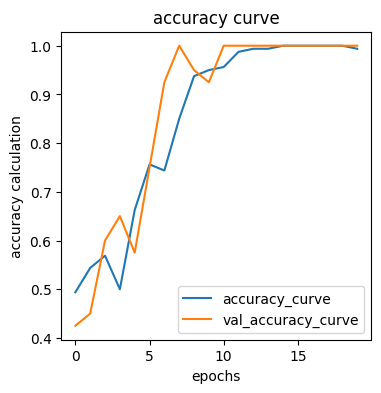

In [11]:
plt.figure(figsize=(4,4))
plt.plot(history.history["accuracy"],label = "accuracy_score")
plt.plot(history.history["val_accuracy"],label = "val_accuracy_score")
plt.title("accuracy curve")
plt.xlabel("epochs")
plt.ylabel("accuracy calculation")
plt.legend(["accuracy_curve","val_accuracy_curve"])
plt.show()

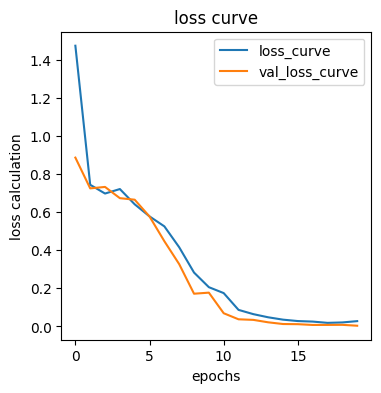

In [12]:
plt.figure(figsize=(4,4))
plt.plot(history.history["loss"],label = "loss_score")
plt.plot(history.history["val_loss"],label = "val_loss_score")
plt.title("loss curve")
plt.xlabel("epochs")
plt.ylabel("loss calculation")
plt.legend(["loss_curve","val_loss_curve"])
plt.show()

In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image

In [14]:
im = image.load_img("D:\\vishal reddy\\animal_dog",target_size=(150,150,3))
img_nor = image.img_to_array(im)/255.0
img_dim = np.expand_dims(img_nor,0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
CAT 😺


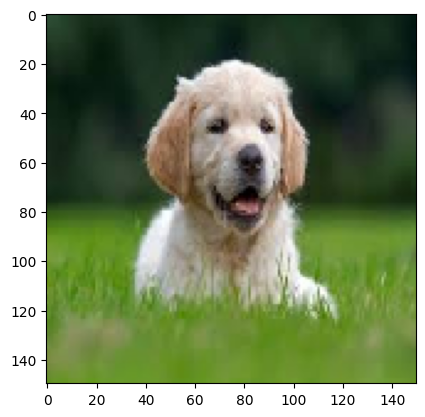

In [15]:
prediction = model.predict(img_dim)
if prediction[0][0] > 0.5:
    print("DOG 🐶")
else:
    print("CAT 😺")
plt.imshow(im)
plt.show()

In [16]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape = (150,150,3)),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu",input_shape = (150,150,3)),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1,activation="sigmoid")
])